In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'Colab Notebooks'	'Копия Временный журнал ЕНУ.gsheet'
 speech_commands_v0.02	'Новая таблица.gsheet'
 test.zip		'Новый документ.gdoc'
 urbu


In [ ]:
!unzip -q /content/drive/MyDrive/test.zip -d /content/dataset/

In [ ]:
import os
print(len(os.listdir('/content/dataset')))

23


In [ ]:
!ls /content/dataset/

'Acne and Rosacea Photos'
'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions'
'Atopic Dermatitis Photos'
'Bullous Disease Photos'
'Cellulitis Impetigo and other Bacterial Infections'
'Eczema Photos'
'Exanthems and Drug Eruptions'
'Hair Loss Photos Alopecia and other Hair Diseases'
'Herpes HPV and other STDs Photos'
'Light Diseases and Disorders of Pigmentation'
'Lupus and other Connective Tissue diseases'
'Melanoma Skin Cancer Nevi and Moles'
'Nail Fungus and other Nail Disease'
'Poison Ivy Photos and other Contact Dermatitis'
'Psoriasis pictures Lichen Planus and related diseases'
'Scabies Lyme Disease and other Infestations and Bites'
'Seborrheic Keratoses and other Benign Tumors'
'Systemic Disease'
'Tinea Ringworm Candidiasis and other Fungal Infections'
'Urticaria Hives'
'Vascular Tumors'
'Vasculitis Photos'
'Warts Molluscum and other Viral Infections'


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/dataset",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print("Класстар саны:", len(class_names))
print(class_names)

Found 4002 files belonging to 23 classes.
Using 3202 files for training.
Found 4002 files belonging to 23 classes.
Using 800 files for validation.
Класстар саны: 23
['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidiasis and other Fungal Infections', 'Urticaria Hives', 'Vascular T

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224,224,3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(23, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 437s 4s/step - accuracy: 0.0920 - loss: 3.2104 - val_accuracy: 0.1088 - val_loss: 2.9239
Epoch 2/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 423s 4s/step - accuracy: 0.1343 - loss: 2.8888 - val_accuracy: 0.1412 - val_loss: 2.8804
Epoch 3/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 420s 4s/step - accuracy: 0.1784 - loss: 2.7936 - val_accuracy: 0.1525 - val_loss: 2.9401
Epoch 4/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 431s 4s/step - accuracy: 0.2290 - loss: 2.6018 - val_accuracy: 0.1725 - val_loss: 3.1989
Epoch 5/5
101/101 ━━━━━━━━━━━━━━━━━━━━ 439s 4s/step - accuracy: 0.3123 - loss: 2.2757 - val_accuracy: 0.1462 - val_loss: 3.9098


In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"gohazhan","key":"64fb72f52b225fc5e218554c9fdc7384"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!pip install -q kaggle

In [4]:
!kaggle datasets list -s skin

ref                                                                title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  ----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                                  Skin Cancer MNIST: HAM10000                     5582914511  2018-09-20 20:36:13.037000         248874       2261  0.7058824        
nodoubttome/skin-cancer9-classesisic                               Skin Cancer ISIC                                1647873564  2019-08-26 18:59:21.257000          32800        302  0.75             
surajghuwalewala/ham1000-segmentation-and-classification           Skin cancer: HAM10000                           2781385274  2021-05-27 09:08:46.813000          18508        137  0.9411765        
pacif

In [5]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.19G/5.20G [01:27<00:00, 15.3MB/s]
100% 5.20G/5.20G [01:27<00:00, 63.6MB/s]


In [6]:
!rm -rf dataset
!unzip -q skin-cancer-mnist-ham10000.zip -d dataset/

In [7]:
import os
os.listdir("dataset")

['HAM10000_images_part_2',
 'HAM10000_images_part_1',
 'HAM10000_metadata.csv',
 'hmnist_28_28_RGB.csv',
 'hmnist_8_8_RGB.csv',
 'ham10000_images_part_1',
 'hmnist_28_28_L.csv',
 'ham10000_images_part_2',
 'hmnist_8_8_L.csv']

In [8]:
import pandas as pd

df = pd.read_csv("dataset/HAM10000_metadata.csv")
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [9]:
df['dx'].value_counts()

,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


In [10]:
import os
import shutil

base_path = "dataset"
image_folders = ["HAM10000_images_part_1", "HAM10000_images_part_2"]

for label in df['dx'].unique():
    os.makedirs(f"dataset/train/{label}", exist_ok=True)

for _, row in df.iterrows():
    img_name = row['image_id'] + ".jpg"
    label = row['dx']

    for folder in image_folders:
        img_path = os.path.join(base_path, folder, img_name)
        if os.path.exists(img_path):
            shutil.copy(img_path, f"dataset/train/{label}/{img_name}")
            break

In [11]:
import os
os.listdir("dataset/train")

['nv', 'df', 'bkl', 'mel', 'vasc', 'bcc', 'akiec']

In [12]:
sum([len(files) for r, d, files in os.walk("dataset/train")])

10015

In [13]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/train",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

print("Класстар:", train_ds.class_names)

Found 10015 files belonging to 7 classes.
Using 8012 files for training.
Found 10015 files belonging to 7 classes.
Using 2003 files for validation.
Класстар: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [15]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(7, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 484s 2s/step - accuracy: 0.6500 - loss: 1.0723 - val_accuracy: 0.7274 - val_loss: 0.7878
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.7258 - loss: 0.7807 - val_accuracy: 0.7444 - val_loss: 0.7225
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 418s 2s/step - accuracy: 0.7480 - loss: 0.7057 - val_accuracy: 0.7519 - val_loss: 0.7104
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.7570 - loss: 0.6719 - val_accuracy: 0.7534 - val_loss: 0.6797
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.7747 - loss: 0.6210 - val_accuracy: 0.7678 - val_loss: 0.6684
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 477s 2s/step - accuracy: 0.7797 - loss: 0.6108 - val_accuracy: 0.7604 - val_loss: 0.6661
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 483s 2s/step - accuracy: 0.7946 - loss: 0.5776 - val_accuracy: 0.7534 - val_loss: 0.6829
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 414s 2s/step - accuracy: 0.7937 - loss: 0.5619 - val_accu

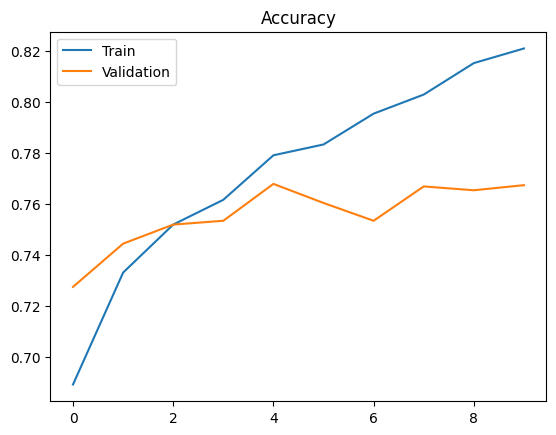

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.title('Accuracy')
plt.show()

In [19]:
from google.colab import files
files.upload()

Saving test_image.png to test_image.png


{'test_image.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01s\x00\x00\x01\x81\x08\x06\x00\x00\x00\x94\xe0Q\x80\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x04gAMA\x00\x00\xb1\x8f\x0b\xfca\x05\x00\x00\x00\tpHYs\x00\x00\x12t\x00\x00\x12t\x01\xdef\x1fx\x00\x00\xff\xa5IDATx^\xec\xbd\x07\xbcoGU\xf7=\xa7\xf7snM\xeeM#$$\xa1\xa94\x01\x05QDQ\xb0ay\x1e\x1b\xfab\x81\xc7\x17\x1f\x15\x01\x1fAEA\x14+\xbd\x88\x824Q\x91\xde[(!\xd4@\x08-\t\xe9\xe5\xa6\xdd^N\xef\xe7\xfd}\x7f3\xeb\x7f\xe6\xec\xfb?\xe7\x9e\x9b\x04\xf4y?\xfe\xee\x9d33k\xd6\xacYS\xf6\x9a\xd9\xb3g\xef\x7f\xc7\xfe\xc9\x95\x95T\xd0\n\x08\x1d\xc5\x87\x06\x07\xf1\x8e \nM\xde:\xde\x89\xd3\x9fN%,+\x01\xbf\x86\xe5U4x\x88\xd6\xb4&\xc8C\x19\xb5\xac\xd0\xbc\x99o=1\x85}]\x90\xaf\xa9k;\xa0/\xc0k\xa7W`i9\xa5\x1e\xb5\x03\xfa\x05\x1f.\xda$\xf4\xc7\xafe\xd6\x88x-\x9ep\xc8\xa4\x9d\x83f\xbff\xfc\x16"\x8ai\xea\x0b\x9a*4\xdb&\xea\x1fu\xae\x01\xa9Kiu{\x81\x10\x11\xbe\x9a\xd6\xe16"N\x1a\xed\xf4@6t\xda3\xca\x89\xb2O\xd4\xc6\xe8\xbe(\x05\xc9C\xff\x0

In [21]:
import os
print(os.listdir())

['.config', 'Снимок экрана 2026-03-07 013218.png', 'skin-cancer-mnist-ham10000.zip', 'test_image.png', 'dataset', 'kaggle.json', 'sample_data']


Бастапқы дерек:


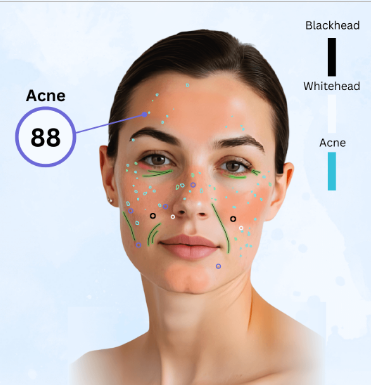

In [22]:
import cv2
from google.colab.patches import cv2_imshow

image_path = "test_image.png"
img = cv2.imread(image_path)

print("Бастапқы дерек:")
cv2_imshow(img)

In [23]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 43.9 MB/s eta 0:00:00


In [25]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO("yolov8n.pt")
results = model.predict(source="test_image.png", save=True)

# The output image from model.predict with save=True is saved to a folder like 'runs/detect/predict/'
# The exact path is usually '/content/runs/detect/predict/test_image.png'
# The error 'AttributeError: 'NoneType' object has no attribute 'clip'' indicates that
# 'result_img' is None, meaning cv2.imread failed to load the image.
# This often happens if the path to the image is incorrect or the file doesn't exist.

# Construct the absolute path to the saved image.
# The `model.predict` output explicitly stated the results were saved to `/content/runs/detect/predict`.
saved_image_path = "/content/runs/detect/predict/test_image.png"
result_img = cv2.imread(saved_image_path)

# Add a check to ensure the image was loaded successfully before displaying
if result_img is not None:
    cv2_imshow(result_img)
else:
    print(f"Error: Could not load image from {saved_image_path}. Please check the path and if the file exists.")


image 1/1 /content/test_image.png: 640x640 1 person, 1 frisbee, 374.3ms
Speed: 11.6ms preprocess, 374.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2
Error: Could not load image from /content/runs/detect/predict/test_image.png. Please check the path and if the file exists.


Соңғы папка: predict2
Файлдар: ['test_image.jpg']
Жүктелетін файл: runs/detect/predict2/test_image.jpg


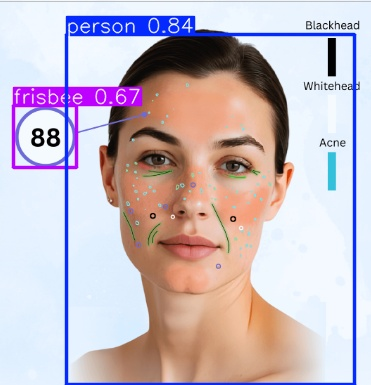

In [27]:
import os
import cv2
from google.colab.patches import cv2_imshow

latest_folder = sorted(os.listdir("runs/detect"))[-1]
print("Соңғы папка:", latest_folder)

files = os.listdir(f"runs/detect/{latest_folder}")
print("Файлдар:", files)

result_path = f"runs/detect/{latest_folder}/{files[0]}"
print("Жүктелетін файл:", result_path)

img = cv2.imread(result_path)
cv2_imshow(img)